### sklearn.feature_selection.mutual_info_classif(X, y, *, discrete_features='auto', n_neighbors=3, copy=True, random_state=None, n_jobs=None)[source]
Estimate mutual information for a discrete target variable.

Mutual information (MI) [1] between two random variables is a non-negative value, which measures the dependency between the variables. It is equal to zero if and only if two random variables are independent, and higher values mean higher dependency.

The function relies on nonparametric methods based on entropy estimation from k-nearest neighbors distances as described in [2] and [3]. Both methods are based on the idea originally proposed in [4].

It can be used for univariate features selection, read more in the User Guide.

In [1]:
import pandas as pd

In [6]:
df=pd.read_csv('https://gist.githubusercontent.com/tijptjik/9408623/raw/b237fa5848349a14a14e5d4107dc7897c21951f5/wine.csv')
df.head()

,Wine,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [3]:
df.shape

(178, 14)

In [8]:
X=df.drop('Wine',axis=1)
y=df["Wine"]

In [9]:
from sklearn.model_selection import train_test_split 
x_train,x_test,y_train,y_test=train_test_split(X,y,random_state=0,test_size=0.3)

In [10]:
from sklearn.feature_selection import mutual_info_classif 
select_feature=mutual_info_classif(x_train,y_train)

In [11]:
select_feature

array([0.42297822, 0.3037352 , 0.18222601, 0.26911138, 0.2027924 ,
       0.47180897, 0.71866543, 0.13800646, 0.26461014, 0.62606852,
       0.562539  , 0.54619968, 0.53719649])

In [15]:
select_feature=pd.Series(select_feature)

In [16]:
select_feature.index=x_train.columns

In [18]:
select_feature.sort_values(ascending=False)

Flavanoids              0.718665
Color.int               0.626069
Hue                     0.562539
OD                      0.546200
Proline                 0.537196
Phenols                 0.471809
Alcohol                 0.422978
Malic.acid              0.303735
Acl                     0.269111
Proanth                 0.264610
Mg                      0.202792
Ash                     0.182226
Nonflavanoid.phenols    0.138006
dtype: float64

<Axes: >

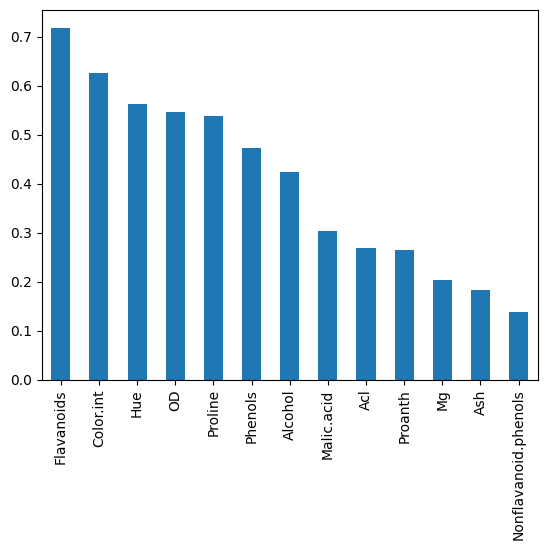

In [19]:
select_feature.sort_values(ascending=False).plot.bar()

In [20]:
# For select only 10 feature abs
from sklearn.feature_selection import SelectKBest
selected_feature=SelectKBest(mutual_info_classif,k=5)

In [22]:
selected_feature.fit(x_train,y_train)

SelectKBest(k=5,
            score_func=<function mutual_info_classif at 0x0000027C7F9036A0>)

In [26]:
selected_feature.get_support()

array([False, False, False, False, False, False,  True, False, False,
        True,  True,  True,  True])

In [35]:
x_train.columns[selected_feature.get_support()]

Index(['Flavanoids', 'Color.int', 'Hue', 'OD', 'Proline'], dtype='object')

In [36]:
selected_feature.get_feature_names_out()

array(['Flavanoids', 'Color.int', 'Hue', 'OD', 'Proline'], dtype=object)